# Research Notebook 01: Hotel Metadata Analysis
**Delhi NCR Trust-Aware Recommender System Dataset**

This notebook performs a detailed analysis of the hotel metadata, including spatial distributions, rating characteristics, and data quality/missing-value checks. Figures are exported for inclusion in research reports.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import os

# Custom Seaborn styling for publication quality figures
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.titlesize': 18,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'figure.figsize': (10, 6)
})

FIG_DIR = '../reports/figures/'
os.makedirs(FIG_DIR, exist_ok=True)
print('Imports completed and figure directory verified.')

Imports completed and figure directory verified.


## 1. Data Quality Checks & Loading
We load `delhi_hotels_cleaned.csv` and inspect it for data quality issues, missing values, and data types.

In [2]:
df_hotels = pd.read_csv('../../data/processed/cleaned/delhi_hotels_cleaned.csv')
print(f'Shape of Hotel Dataset: {df_hotels.shape}')
print('\n--- Column Information & Missing Values ---')
info_df = pd.DataFrame({
    'DataType': df_hotels.dtypes,
    'NullCount': df_hotels.isnull().sum(),
    'NullPct': (df_hotels.isnull().sum() / len(df_hotels)) * 100
})
print(info_df)

print('\n--- First 3 Records ---')
df_hotels.head(3)

Shape of Hotel Dataset: (1661, 11)

--- Column Information & Missing Values ---
                DataType  NullCount     NullPct
hotel_id             str          0    0.000000
google_place_id      str          0    0.000000
hotel_name           str          0    0.000000
address              str          0    0.000000
latitude         float64          0    0.000000
longitude        float64          0    0.000000
rating           float64          8    0.481638
review_count     float64          8    0.481638
area                 str          2    0.120409
hotel_type           str          0    0.000000
price_level      float64       1661  100.000000

--- First 3 Records ---


,hotel_id,google_place_id,hotel_name,address,latitude,longitude,rating,review_count,area,hotel_type,price_level
0,ChIJpV-ywbQVDTkRqWm6FgM6WCM,ChIJpV-ywbQVDTkRqWm6FgM6WCM,Haveli Hotel & Family Restaurant,"Pataudi Road, 13 Milestone, NH-352, near CNG P...",28.410669,76.892914,4.6,102.0,near CNG Pump,hotel,NaN
1,ChIJm053GEI-DTkRwKJuNdfAyLw,ChIJm053GEI-DTkRwKJuNdfAyLw,Jps Residency & Hospitality Services,"opp. 446 E, Sector 8, Imt Manesar, Gurugram",28.381003,76.886461,3.9,1714.0,Imt Manesar,hotel,NaN
2,ChIJkTyoKUkVDTkR8L5-ZWny4t8,ChIJkTyoKUkVDTkR8L5-ZWny4t8,Hotel O Royal Guest House,"13, Gurugram Rd, Sector 11, Farukh Nagar",28.446600,76.831032,4.0,162.0,Sector 11,hotel,NaN


### Missing Values Visualization
We plot the missing value percentages across the metadata attributes.

C:\Users\skesh\AppData\Local\Temp\ipykernel_31312\1271560644.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=null_pcts.index, y=null_pcts.values, palette='coolwarm')


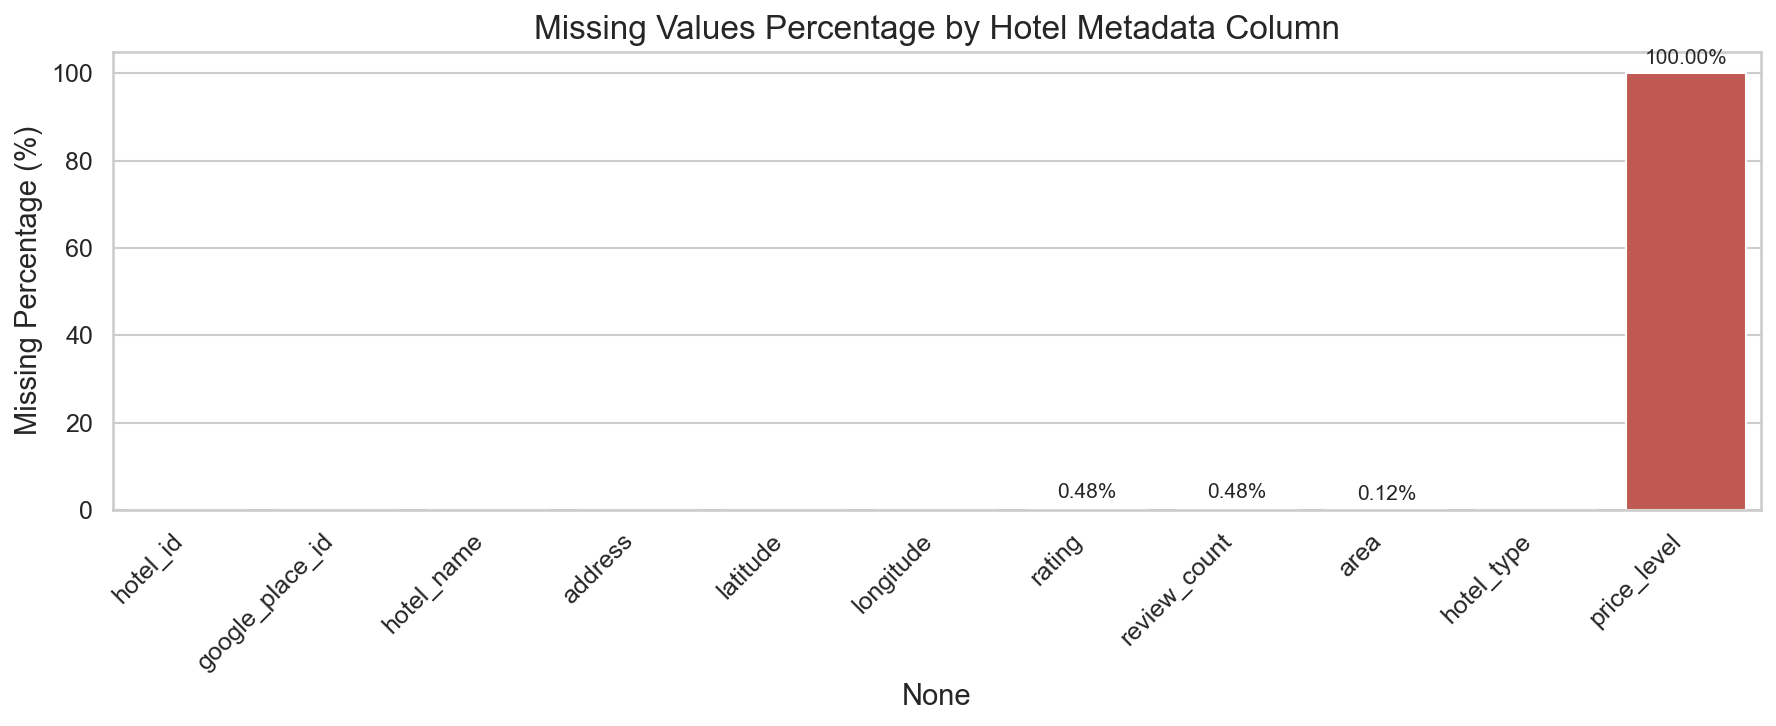

In [3]:
plt.figure(figsize=(12, 5))
null_pcts = df_hotels.isnull().sum() / len(df_hotels) * 100
ax = sns.barplot(x=null_pcts.index, y=null_pcts.values, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Values Percentage by Hotel Metadata Column')
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height + 1), 
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_missing_values.png'))
plt.show()

**Interpretation & Key Insight:**
> `price_level` is 100% missing (1661 null values) due to API retrieval limits or pricing opacity. All other columns are extremely clean: `rating` and `review_count` have only 8 missing records (0.48%), and `area` has 2 (0.12%). This confirms excellent coverage except for price level, which we will address via budget feature engineering later.

## 2. Geographic Distribution of Hotels
We plot the hotels in Delhi NCR using an interactive Mapbox plot and a static research paper plot.

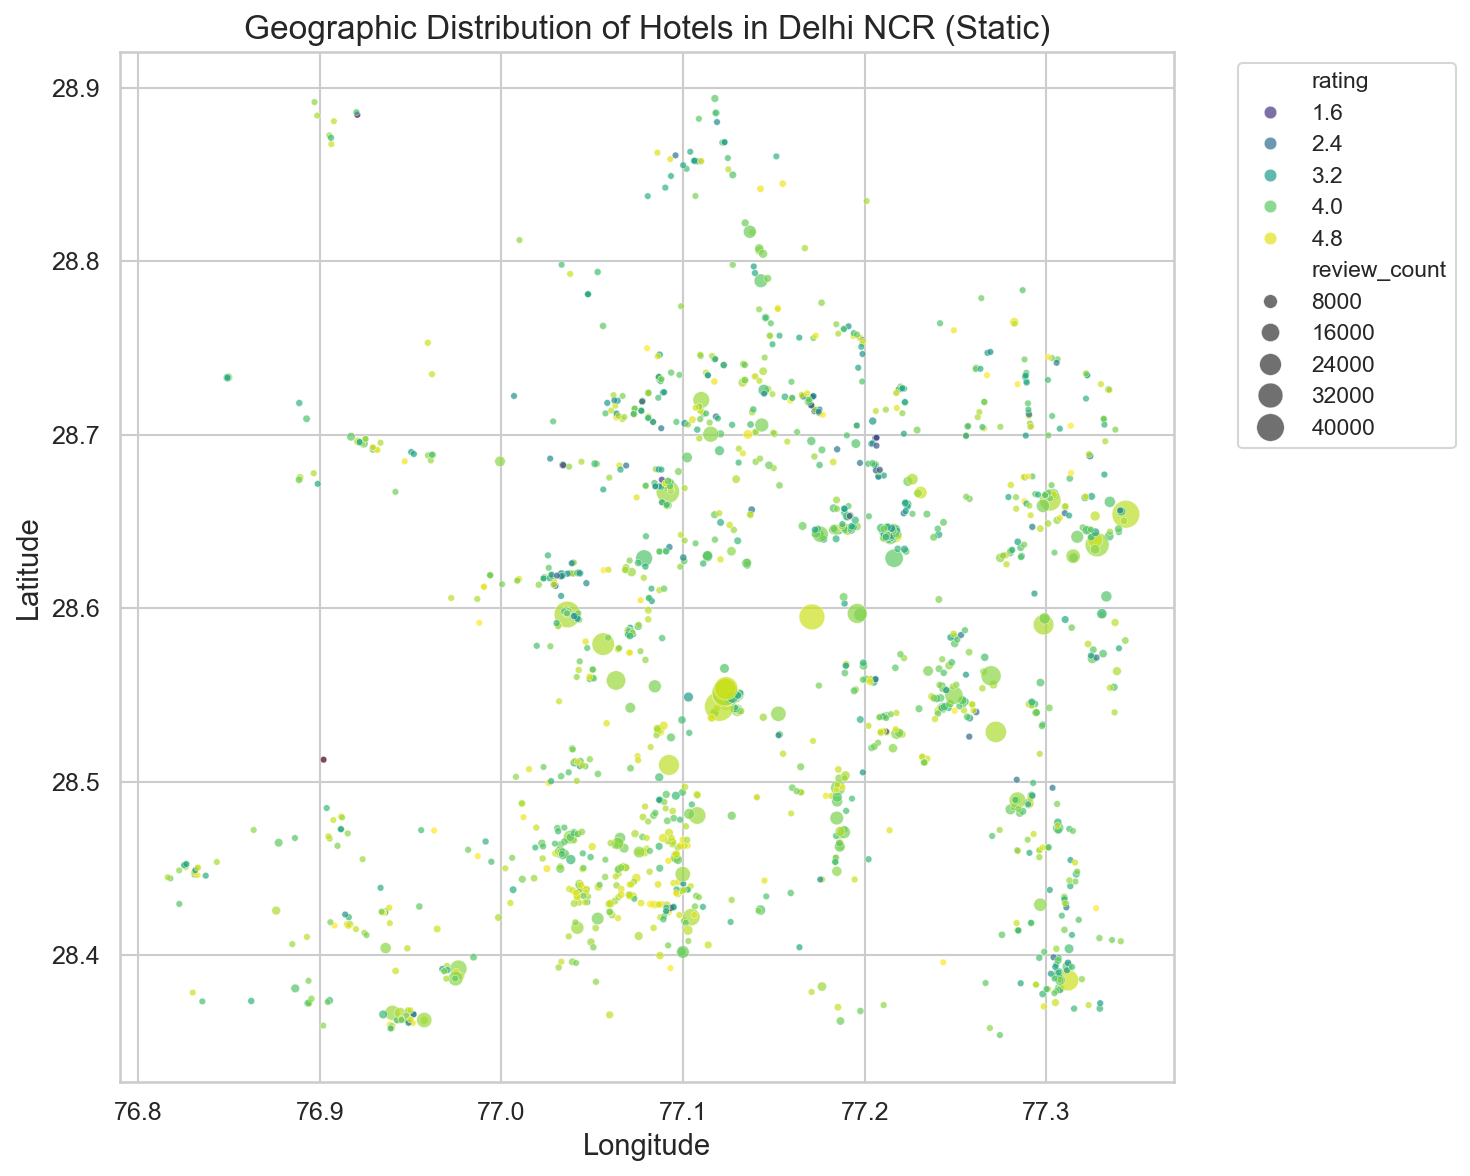

In [4]:
# Static Scatter Plot for Research Paper
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_hotels, x='longitude', y='latitude', hue='rating', palette='viridis', size='review_count', sizes=(10, 200), alpha=0.7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Hotels in Delhi NCR (Static)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_hotel_map.png'))
plt.show()

In [5]:
# Interactive Plotly Map
map_df = df_hotels.dropna(subset=['latitude', 'longitude', 'rating', 'review_count']).copy()
fig = px.scatter_mapbox(
    map_df,
    lat='latitude',
    lon='longitude',
    hover_name='hotel_name',
    hover_data=['area', 'rating', 'review_count'],
    color='rating',
    size='review_count',
    color_continuous_scale=px.colors.cyclical.IceFire,
    zoom=9,
    title='Interactive Geographic Distribution of Delhi NCR Hotels'
)
fig.update_layout(mapbox_style='open-street-map')
fig.update_layout(margin={'r':0,'t':40,'l':0,'b':0})
fig.show()

C:\Users\skesh\AppData\Local\Temp\ipykernel_31312\3386962868.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


**Interpretation & Key Insight:**
> The geographic plots show heavy clustering of hotels in central New Delhi (Paharganj, Karol Bagh), Gurugram, and near the Airport (Mahipalpur). There is a long tail of hotels scattered across outlying Delhi NCR sectors, ensuring representation of diverse locations.

## 3. Rating & Review Count Distributions
We look at how hotel ratings and review counts are distributed.

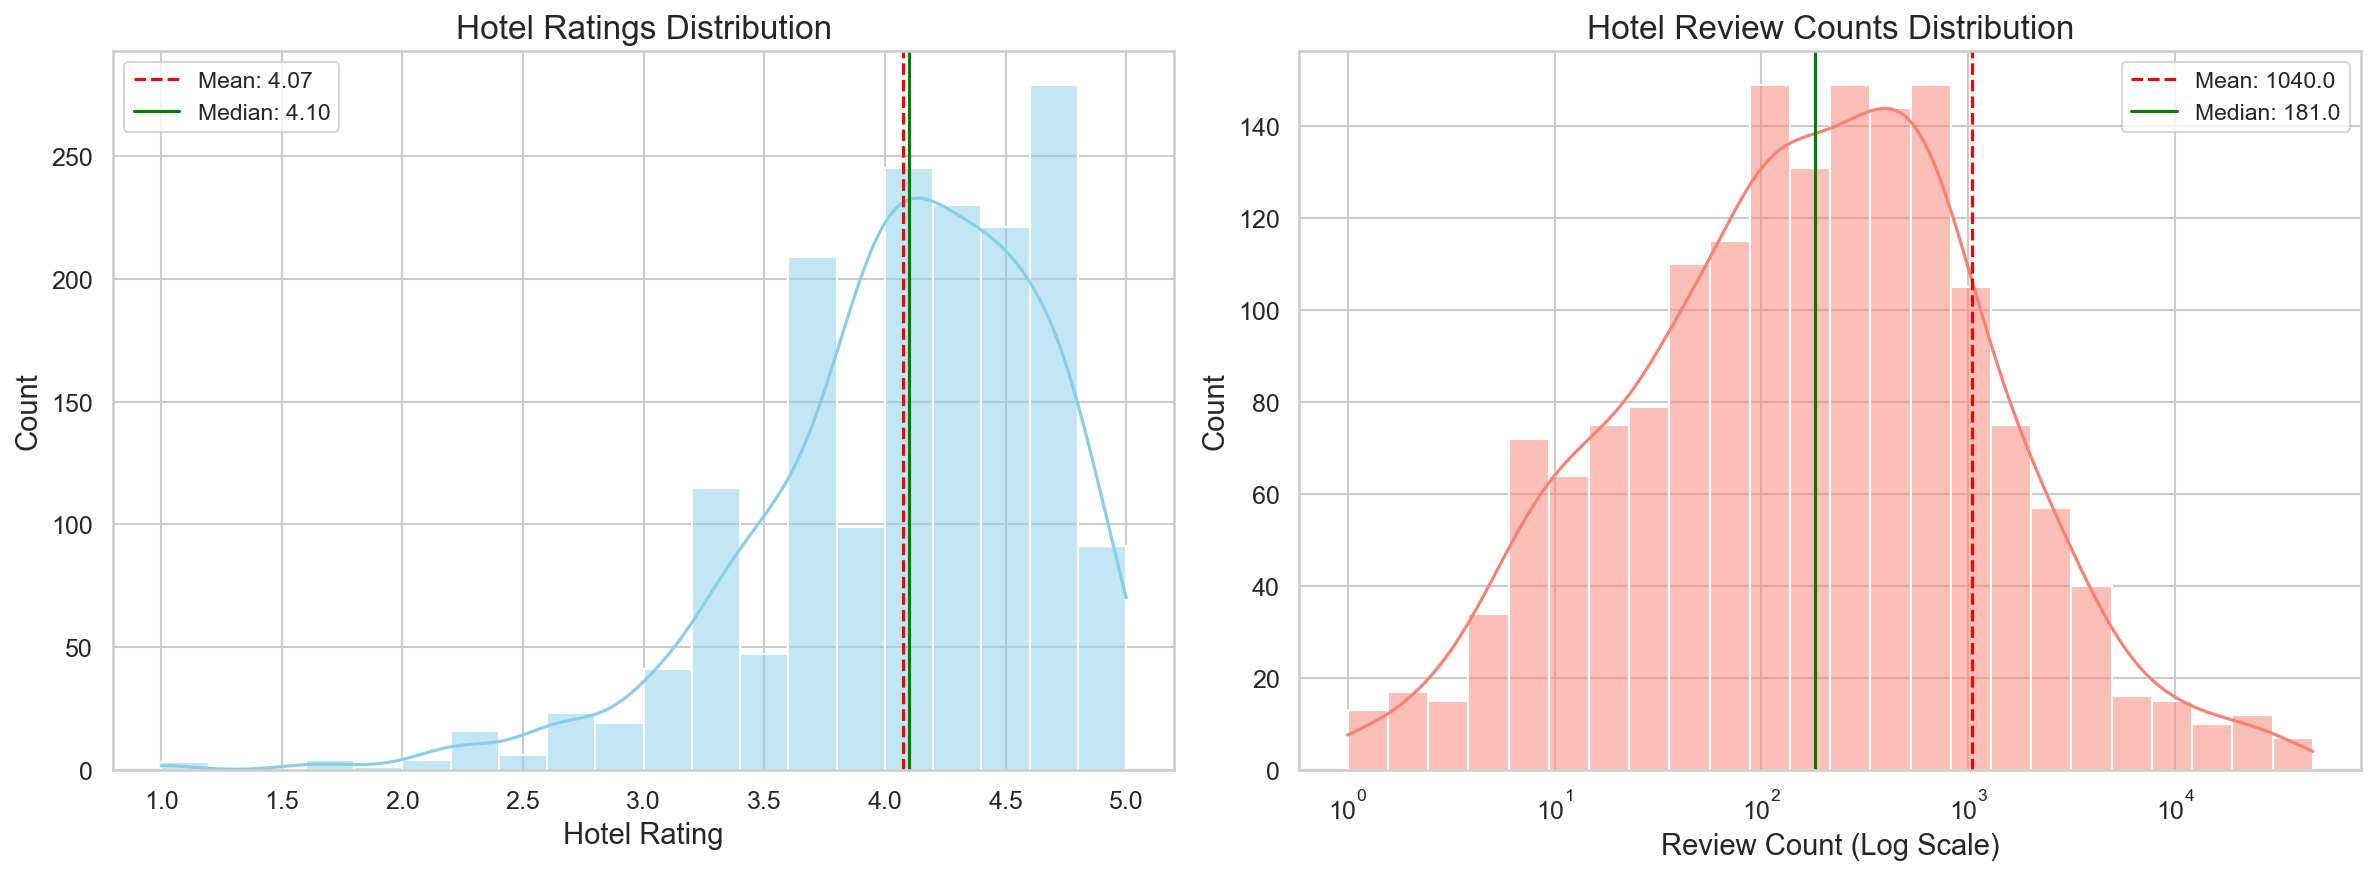

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rating Distribution
sns.histplot(data=df_hotels.dropna(subset=['rating']), x='rating', kde=True, bins=20, ax=axes[0], color='skyblue')
axes[0].axvline(df_hotels['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df_hotels["rating"].mean():.2f}')
axes[0].axvline(df_hotels['rating'].median(), color='green', linestyle='-', label=f'Median: {df_hotels["rating"].median():.2f}')
axes[0].set_xlabel('Hotel Rating')
axes[0].set_title('Hotel Ratings Distribution')
axes[0].legend()

# Review Count Distribution (Log Scale)
sns.histplot(data=df_hotels.dropna(subset=['review_count']), x='review_count', log_scale=True, kde=True, ax=axes[1], color='salmon')
axes[1].axvline(df_hotels['review_count'].mean(), color='red', linestyle='--', label=f'Mean: {df_hotels["review_count"].mean():.1f}')
axes[1].axvline(df_hotels['review_count'].median(), color='green', linestyle='-', label=f'Median: {df_hotels["review_count"].median():.1f}')
axes[1].set_xlabel('Review Count (Log Scale)')
axes[1].set_title('Hotel Review Counts Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_ratings_reviews.png'))
plt.show()

**Interpretation & Key Insight:**
> Hotel ratings are negatively skewed with a median of 4.10, showing a strong rating inflation typical of online services. The review counts follow a highly skewed log-normal long-tail distribution: while some hotels have thousands of reviews, the median review count is very low. This long-tail effect suggests sparsity challenges for recommender systems.

## 4. Area & Type Analysis & Statistical Summaries
Let's look at counts of hotels per area and types.

In [7]:
print('--- Statistical summary of ratings and reviews ---')
print(df_hotels[['rating', 'review_count']].describe())

print('\n--- Top 15 Areas by Hotel Count ---')
area_counts = df_hotels['area'].value_counts()
print(area_counts.head(15))

print('\n--- Hotel Types Distribution ---')
type_counts = df_hotels['hotel_type'].value_counts()
print(type_counts)

--- Statistical summary of ratings and reviews ---
            rating  review_count
count  1653.000000   1653.000000
mean      4.074047   1040.045977
std       0.597957   3477.211083
min       1.000000      1.000000
25%       3.800000     41.000000
50%       4.100000    181.000000
75%       4.500000    643.000000
max       5.000000  46272.000000

--- Top 15 Areas by Hotel Count ---
area
New Delhi                  216
Rohini                      61
Mahipalpur                  56
Gurugram                    39
Paharganj                   38
Dwarka                      32
New Industrial Township     31
Delhi                       26
Karol Bagh                  23
Sector 43                   20
Shahdara                    20
Imt Manesar                 19
Chhatarpur                  18
Loni                        18
Manesar                     17
Name: count, dtype: int64

--- Hotel Types Distribution ---
hotel_type
hotel    1661
Name: count, dtype: int64


C:\Users\skesh\AppData\Local\Temp\ipykernel_31312\3923577306.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=area_counts.head(15).values, y=area_counts.head(15).index, palette='viridis')


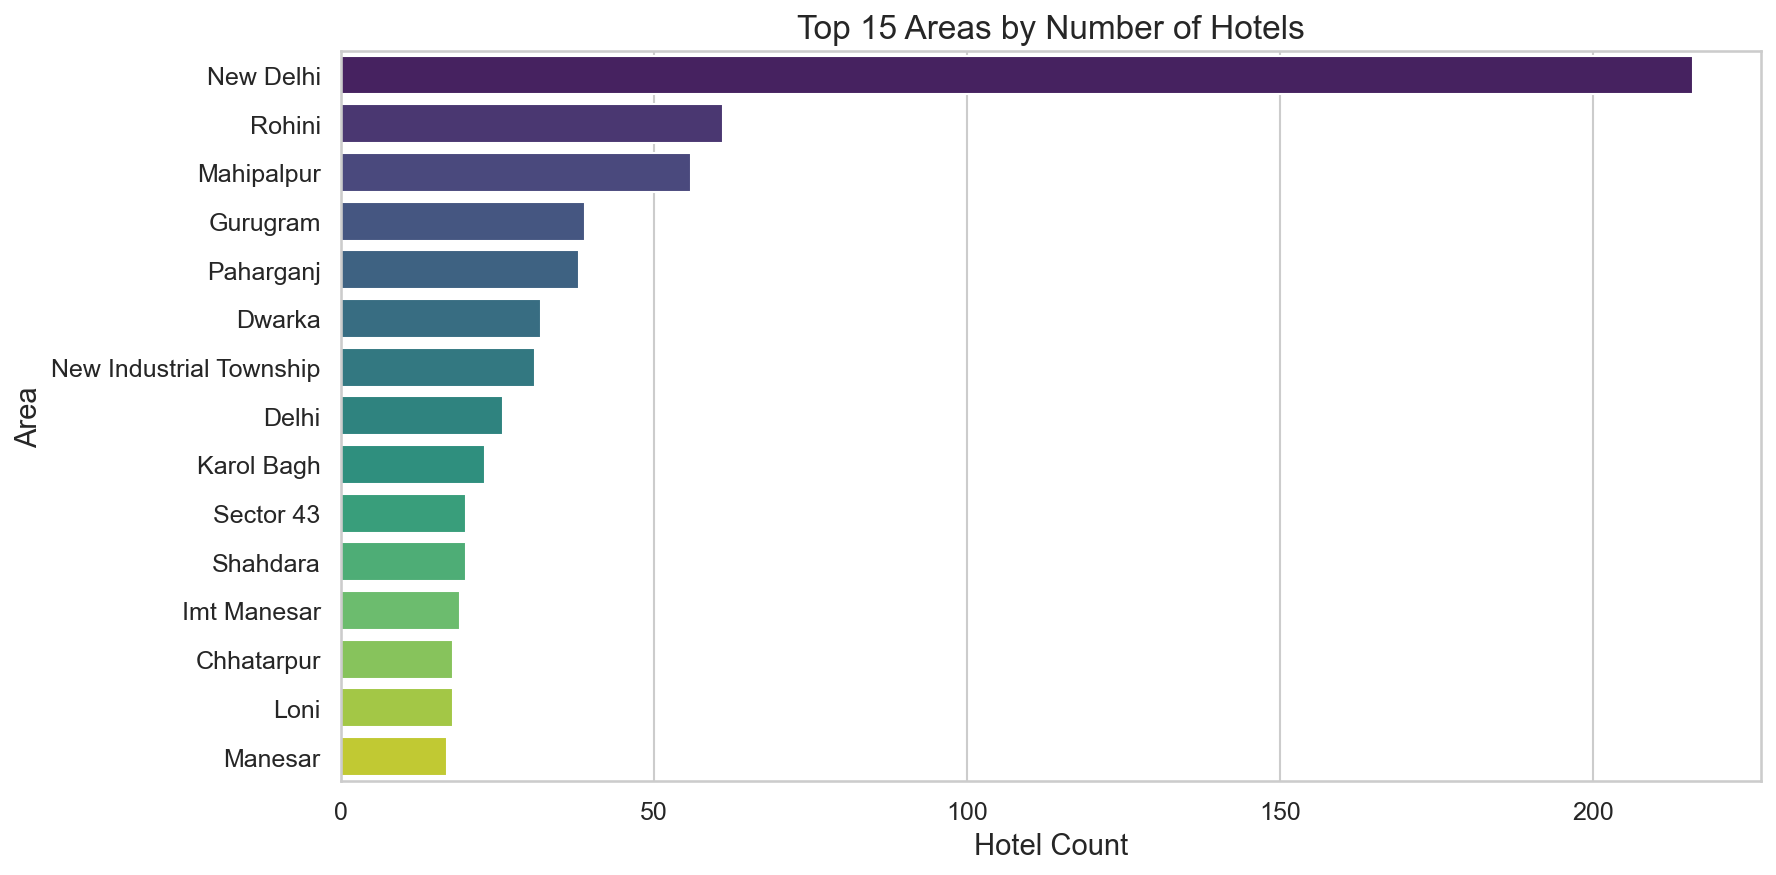

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(x=area_counts.head(15).values, y=area_counts.head(15).index, palette='viridis')
plt.xlabel('Hotel Count')
plt.ylabel('Area')
plt.title('Top 15 Areas by Number of Hotels')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '01_top_areas.png'))
plt.show()

**Interpretation & Key Insight:**
> New Delhi dominates with 216 hotels, followed by Rohini (61) and Mahipalpur (56). A large portion (946 hotels) falls under 'Other' smaller locations, emphasizing the need for robust geospatial aggregation/clustering in our recommender models.